90%

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the Fire module (core component of SqueezeNet)
def fire_module(x, squeeze_filters, expand_filters):
    # Squeeze layer
    squeeze = layers.Conv2D(squeeze_filters, (1, 1), padding='same', activation='relu')(x)
    
    # Expand layer
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), padding='same', activation='relu')(squeeze)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='relu')(squeeze)
    
    # Concatenate the expand outputs
    x = layers.Concatenate()([expand1x1, expand3x3])
    
    return x

# Define Squeeze-and-Excitation block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Reshape((1, 1, filters))(se)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    x = layers.Multiply()([input_tensor, se])
    return x

# Define SqueezeNet architecture with SE blocks
def create_squeezenet(input_shape=(224, 224, 3), classes=5):
    inputs = layers.Input(shape=input_shape)

    # Initial Conv Layer
    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)
    
    # Fire modules with reduced parameters
    x = fire_module(x, squeeze_filters=16, expand_filters=32)
    x = fire_module(x, squeeze_filters=16, expand_filters=32)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)
    
    x = fire_module(x, squeeze_filters=32, expand_filters=64)
    x = fire_module(x, squeeze_filters=32, expand_filters=64)
    
    # Add Squeeze-and-Excitation block to the final fire module
    x = squeeze_excite_block(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Dropout for regularization
    x = layers.Dropout(0.5)(x)

    # Output layer with softmax activation for 5 classes
    outputs = layers.Dense(classes, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model

# Create the SqueezeNet model
model = create_squeezenet()

# Compile the model using categorical crossentropy for multiclass classification
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_25 (Conv2D)             (None, 112, 112, 64  1792        ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d_3 (MaxPooling2D)  (None, 55, 55, 64)  0           ['conv2d_25[0][0]']              
                                                                                            

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Define image data generators for training and validation datasets
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
train_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\train',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

validation_generator = val_datagen.flow_from_directory(
    r"C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\val",
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

# Train the model for 50 epochs
history = model.fit(
    train_generator,
    epochs=50, 
    validation_data=validation_generator
)

Found 8883 images belonging to 5 classes.
Found 1113 images belonging to 5 classes.
Epoch 1/50
1111/1111 [==============================] - 23s 19ms/step - loss: 0.9655 - accuracy: 0.6238 - val_loss: 0.4700 - val_accuracy: 0.8724
Epoch 2/50
1111/1111 [==============================] - 26s 23ms/step - loss: 0.5105 - accuracy: 0.8576 - val_loss: 0.7541 - val_accuracy: 0.7367
Epoch 3/50
1111/1111 [==============================] - 28s 26ms/step - loss: 0.4384 - accuracy: 0.8735 - val_loss: 0.3717 - val_accuracy: 0.8841
Epoch 4/50
1111/1111 [==============================] - 22s 20ms/step - loss: 0.4086 - accuracy: 0.8775 - val_loss: 0.3753 - val_accuracy: 0.8814
Epoch 5/50
1111/1111 [==============================] - 17s 15ms/step - loss: 0.4051 - accuracy: 0.8780 - val_loss: 0.3644 - val_accuracy: 0.8859
Epoch 6/50
1111/1111 [==============================] - 18s 16ms/step - loss: 0.3767 - accuracy: 0.8834 - val_loss: 0.3503 - val_accuracy: 0.9021
Epoch 7/50
1111/1111 [==================

In [13]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
test_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

Found 1110 images belonging to 5 classes.
139/139 [==============================] - 41s 291ms/step - loss: 0.3536 - accuracy: 0.9090
Test Accuracy: 0.9090089797973633


In [1]:
model.save(r"C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet_aug.h5")

# import pickle
# with open('training_history.pkl', 'wb') as f:
#     pickle.dump(history.history, f)

NameError: name 'model' is not defined

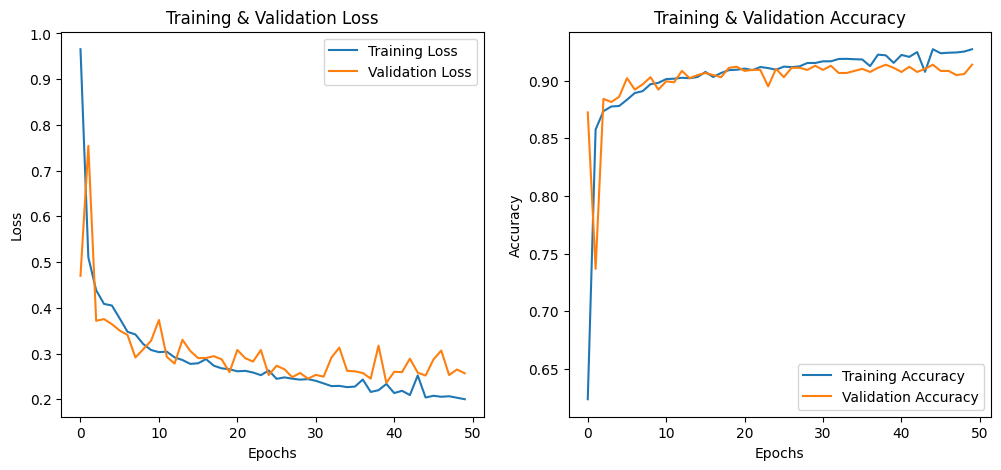

In [11]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(history):
    # Plot Training & Validation Loss
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# After training the model, pass the history object to the function
plot_loss_accuracy(history)

In [12]:
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the saved model
model = load_model(r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet_aug.h5')

# Define image data generator for validation dataset
val_datagen = ImageDataGenerator(rescale=1./255)

# Load validation dataset from directory
validation_generator = val_datagen.flow_from_directory(
    r"C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\val",
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss}, Validation Accuracy: {accuracy}")


Found 1113 images belonging to 5 classes.
140/140 [==============================] - 2s 11ms/step - loss: 0.2568 - accuracy: 0.9137
Validation Loss: 0.25680601596832275, Validation Accuracy: 0.9137466549873352


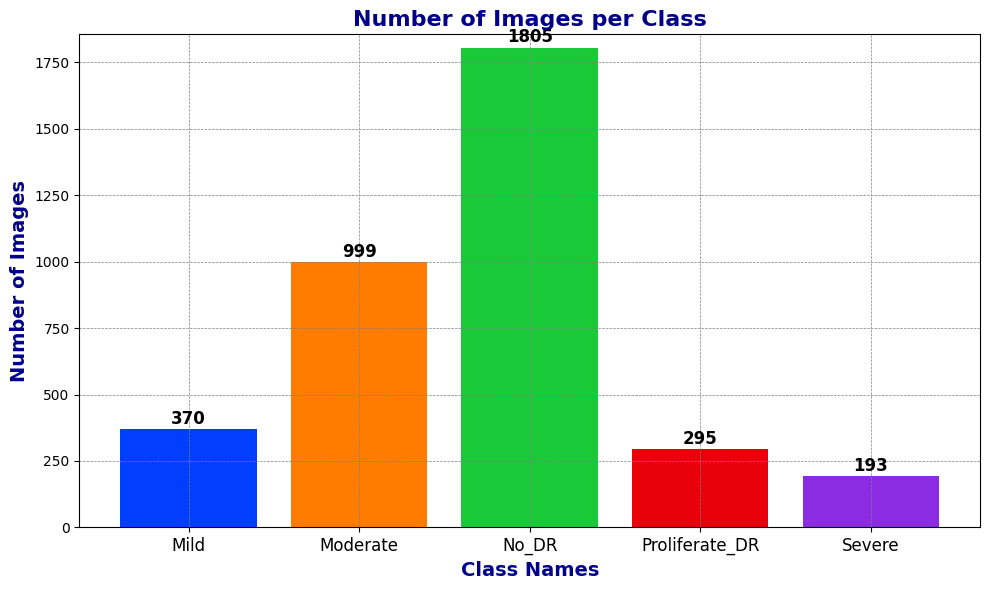

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to dataset directory
dataset_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\colored_images'

# Get the number of images in each class
class_names = []
image_counts = []

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_names.append(class_folder)
        image_counts.append(num_images)

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Use a bright color palette
palette = sns.color_palette("bright", len(class_names))
bars = ax.bar(class_names, image_counts, color=palette)

# Add number of images on top of each bar in bold
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{height}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add grids (both horizontal and vertical)
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='gray')

# Set the x-axis labels to be horizontal
plt.xticks(rotation=0, fontsize=12)

# Set plot title and labels
ax.set_title('Number of Images per Class', fontsize=16, color='darkblue', fontweight='bold')
ax.set_xlabel('Class Names', fontsize=14, color='darkblue', fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=14, color='darkblue', fontweight='bold')

# Adjust the y-axis to ensure visibility of text above bars
ax.set_ylim(0, max(image_counts) + 50)

# Show the plot
plt.tight_layout()
plt.show()


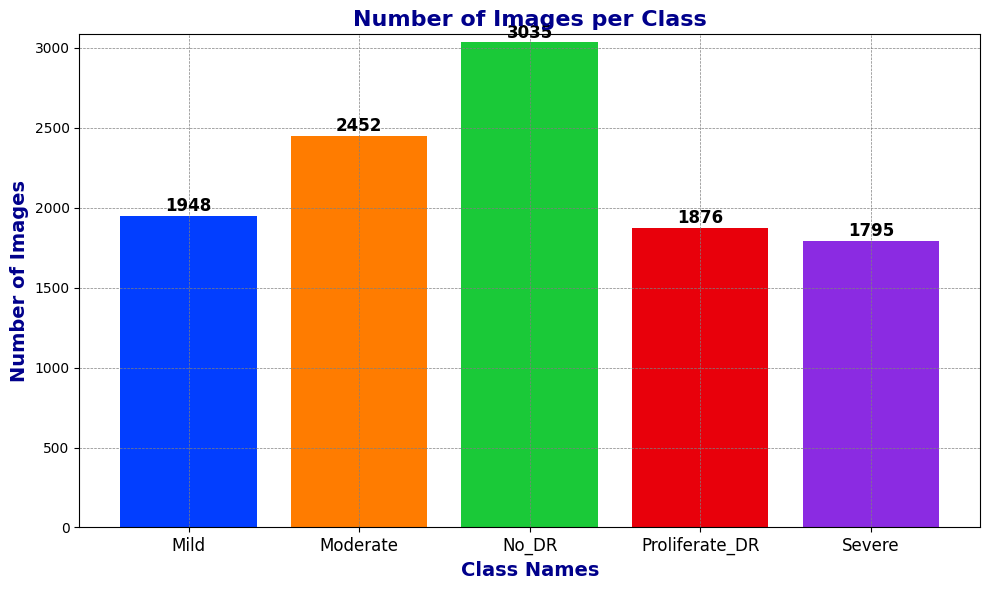

In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to dataset directory
dataset_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\augmented_data'

# Get the number of images in each class
class_names = []
image_counts = []

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_names.append(class_folder)
        image_counts.append(num_images)

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Use a bright color palette
palette = sns.color_palette("bright", len(class_names))
bars = ax.bar(class_names, image_counts, color=palette)

# Add number of images on top of each bar in bold
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{height}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add grids (both horizontal and vertical)
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='gray')

# Set the x-axis labels to be horizontal
plt.xticks(rotation=0, fontsize=12)

# Set plot title and labels
ax.set_title('Number of Images per Class', fontsize=16, color='darkblue', fontweight='bold')
ax.set_xlabel('Class Names', fontsize=14, color='darkblue', fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=14, color='darkblue', fontweight='bold')

# Adjust the y-axis to ensure visibility of text above bars
ax.set_ylim(0, max(image_counts) + 50)

# Show the plot
plt.tight_layout()
plt.show()


In [16]:
import os
import pandas as pd
import numpy as np
from keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# Function to predict labels using a given model
def generate_pred_labels(model_path, test_data_dir, output_csv_path):
    # Load the trained model
    model = load_model(model_path)
    
    # Create a list to hold the image file names and their corresponding predicted labels
    pred_data = []

    # Iterate through each class folder in the test dataset
    for class_folder in os.listdir(test_data_dir):
        class_path = os.path.join(test_data_dir, class_folder)
        
        if os.path.isdir(class_path):
            # List all images in the class folder
            for image_name in os.listdir(class_path):
                # Load and preprocess the image
                image_path = os.path.join(class_path, image_name)
                image = load_img(image_path, target_size=(224, 224))  # Adjust the target size based on your model's input
                image_array = img_to_array(image) / 255.0  # Normalize the image
                image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension

                # Make prediction
                pred = model.predict(image_array)
                predicted_label = np.argmax(pred, axis=1)[0]  # Get the index of the highest probability
                
                # Append the image file name and its predicted label to the pred_data list
                pred_data.append({'id_code': image_name, 'predicted_diagnosis': predicted_label})

    # Create a DataFrame and save to CSV
    pred_labels_df = pd.DataFrame(pred_data)
    pred_labels_df.to_csv(output_csv_path, index=False)

    print("CSV file with predicted labels created successfully.")

# Example usage
model_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet_aug.h5'  # Path to your trained model
test_data_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test'  # Path to your test images
output_csv_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\pred_label_squeezenet.csv'  # Path for the output CSV file

# Call the function to generate predicted labels
generate_pred_labels(model_path, test_data_dir, output_csv_path)


1/1 [==============================] - 0s 70ms/step
CSV file with predicted labels created successfully.


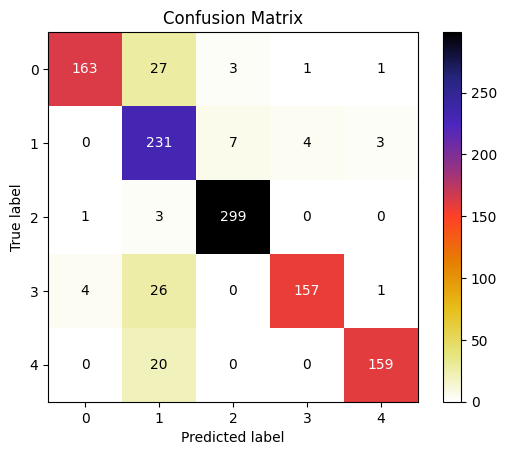

In [17]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Paths to the CSV files
true_labels_path = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test_true_labels.csv'  # Update this path
predicted_labels_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\pred_label_squeezenet.csv'  # Update this path

# Load true labels CSV (assumed to have a 'diagnosis' column for the actual labels)
true_labels_df = pd.read_csv(true_labels_path)
true_labels = true_labels_df['diagnosis'].values

# Load predicted labels CSV (assumed to have a 'diagnosis' column for the predicted labels)
predicted_labels_df = pd.read_csv(predicted_labels_path)
predicted_labels = predicted_labels_df['predicted_diagnosis'].values

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4])
disp.plot(cmap='CMRmap_r')

# Add grid and title for better clarity
plt.grid(False)  # Confusion matrix already includes its own grid
plt.title('Confusion Matrix')
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


# Load true and predicted labels from CSVs
true_df = pd.read_csv(true_labels_path)
pred_df = pd.read_csv(predicted_labels_path)

# Ensure that both dataframes have the same length
assert len(true_df) == len(pred_df), "Mismatch in number of true and predicted labels."

# Extract the true labels and predicted labels
y_true = true_df['diagnosis'].values  # True labels column in CSV
y_pred = pred_df['predicted_diagnosis'].values  # Predicted labels column in CSV

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']  # Modify based on your classes

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:

                precision    recall  f1-score   support

         No_DR       0.97      0.84      0.90       195
          Mild       0.75      0.94      0.84       245
      Moderate       0.97      0.99      0.98       303
        Severe       0.97      0.84      0.90       188
Proliferate_DR       0.97      0.89      0.93       179

      accuracy                           0.91      1110
     macro avg       0.93      0.90      0.91      1110
  weighted avg       0.92      0.91      0.91      1110



In [3]:
#CORRECT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Paths to the CSV files
true_labels_path = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test_true_labels.csv'  # Update this path
predicted_labels_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\pred_label_squeezenet.csv'  # Update this path


# Load true and predicted labels from CSVs
true_df = pd.read_csv(true_labels_path)
pred_df = pd.read_csv(predicted_labels_path)

# Ensure that both dataframes have the same length
assert len(true_df) == len(pred_df), "Mismatch in number of true and predicted labels."

# Extract the true labels and predicted labels
y_true = true_df['diagnosis'].values  # True labels column in CSV
y_pred = pred_df['predicted_diagnosis'].values  # Predicted labels column in CSV

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR','Severe']  # Modify based on your classes

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:

                precision    recall  f1-score   support

          Mild       0.97      0.84      0.90       195
      Moderate       0.75      0.94      0.84       245
         No_DR       0.97      0.99      0.98       303
Proliferate_DR       0.97      0.84      0.90       188
        Severe       0.97      0.89      0.93       179

      accuracy                           0.91      1110
     macro avg       0.93      0.90      0.91      1110
  weighted avg       0.92      0.91      0.91      1110



Graphs

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # Load your saved model
# model_path = r'C:\MyFolders\Projects\major_project\classification\model.h5'  # Adjust this path
model = load_model(model_path)

# Load true labels
true_labels_csv = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test_true_labels.csv'  # CSV containing true labels
# pred_labels_csv = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\pred_label_squeezenet.csv'
true_df = pd.read_csv(true_labels_csv)

# Load your test dataset
test_data_path = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test'
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Generate test data
test_generator = test_datagen.flow_from_directory(
    test_data_path,
    target_size=(224, 224),  # Adjust according to your model's input size
    class_mode='categorical',
    shuffle=False,
    batch_size=32
)

# Get true labels
y_true = test_generator.classes

# Get predicted probabilities
y_pred_probs = model.predict(test_generator, steps=len(test_generator))

# Check the shape of the predicted probabilities
print("Predicted probabilities shape:", y_pred_probs.shape)


Found 1110 images belonging to 5 classes.
35/35 [==============================] - 2s 42ms/step
Predicted probabilities shape: (1110, 5)


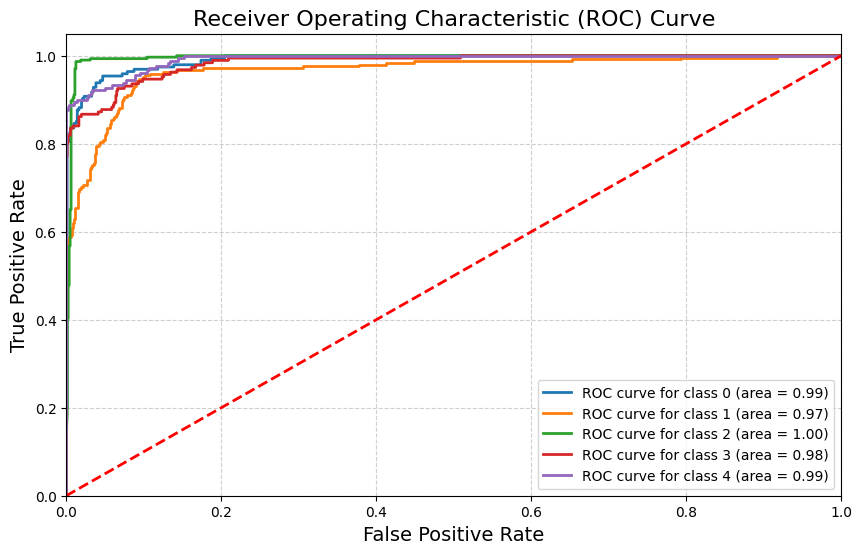

35/35 [==============================] - 2s 41ms/step


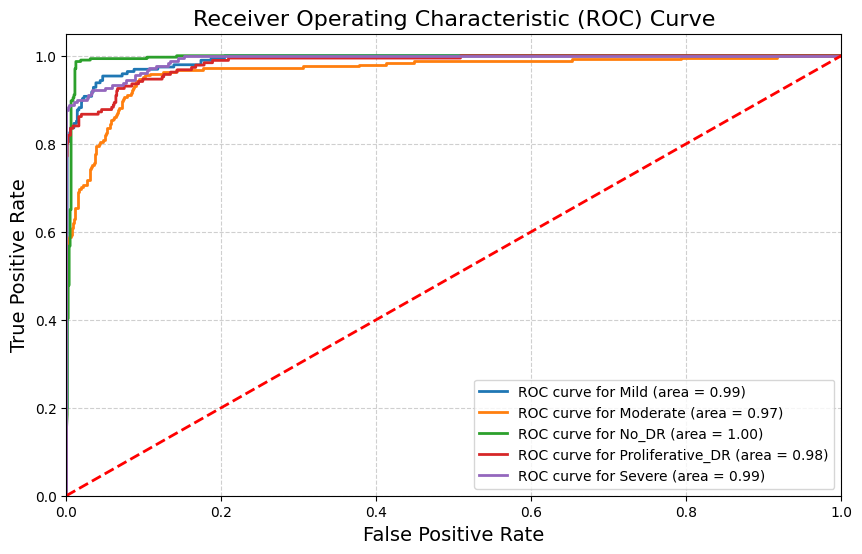

In [31]:
# Calculate ROC curve and AUC
n_classes = y_pred_probs.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true, y_pred_probs[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {} (area = {:.2f})'.format(i, roc_auc[i]))

# Diagonal line
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')

# Plot settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()




# Get true labels
y_true = test_generator.classes

# Get predicted probabilities
y_pred_probs = model.predict(test_generator, steps=len(test_generator))

# Define class names
class_names = ['Mild', 'Moderate', 'No_DR', 'Proliferative_DR', 'Severe']

# Calculate ROC curve and AUC for each class
n_classes = y_pred_probs.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true, y_pred_probs[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves with class names
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for {} (area = {:.2f})'.format(class_names[i], roc_auc[i]))

# Diagonal line for random guessing
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')

# Plot settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

35/35 [==============================] - 2s 33ms/step


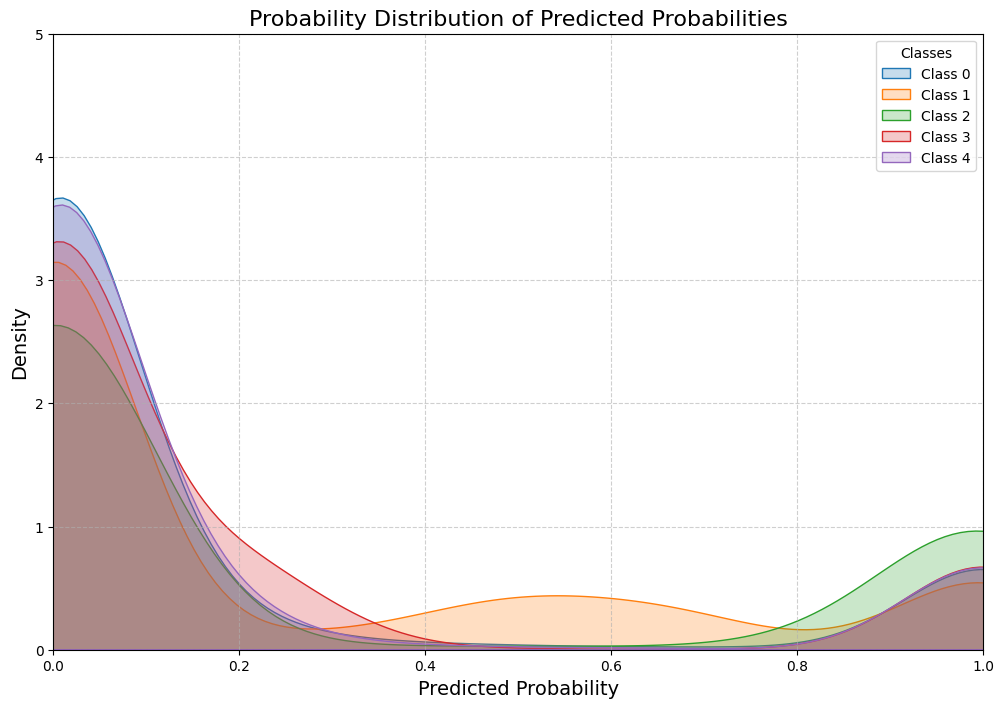

35/35 [==============================] - 1s 35ms/step


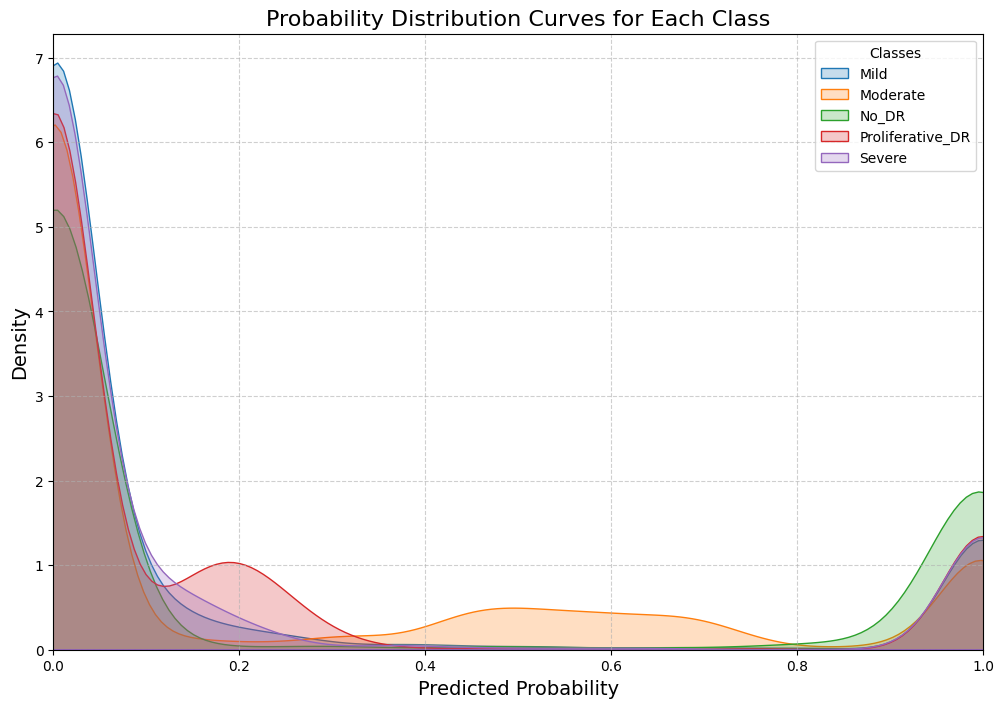

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model = load_model(model_path)

# Load true labels
true_labels_csv = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test_true_labels.csv'  # CSV containing true labels
# pred_labels_csv = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\pred_label_squeezenet.csv'
true_df = pd.read_csv(true_labels_csv)

# Load your test dataset
test_data_path = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test'
test_datagen = ImageDataGenerator(rescale=1.0/255)


# # Get predicted probabilities
y_pred_probs = model.predict(test_generator, steps=len(test_generator))

# Assuming y_pred_probs has shape (num_samples, num_classes)
n_classes = y_pred_probs.shape[1]

# Set up the plot
plt.figure(figsize=(12, 8))

# Plot the probability distribution for each class
for i in range(n_classes):
    sns.kdeplot(y_pred_probs[:, i], label=f'Class {i}', fill=True)

# Plot settings
plt.title('Probability Distribution of Predicted Probabilities', fontsize=16)
plt.xlabel('Predicted Probability', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(0, 1)  # Probability values between 0 and 1
plt.ylim(0, 5)  # Adjust this limit based on your density values
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Classes')
plt.show()

# Get predicted probabilities
y_pred_probs = model.predict(test_generator, steps=len(test_generator))

# Define class names
class_names = ["Mild", "Moderate", "No_DR", "Proliferative_DR", "Severe"]

# Plot the probability distribution curves
plt.figure(figsize=(12, 8))

for i in range(len(class_names)):
    sns.kdeplot(y_pred_probs[:, i], label=class_names[i], bw_adjust=0.5, fill=True)  # You can adjust the bandwidth if needed

# Plot settings
plt.title('Probability Distribution Curves for Each Class', fontsize=16)
plt.xlabel('Predicted Probability', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Classes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 1)  # Probability ranges from 0 to 1
plt.show()

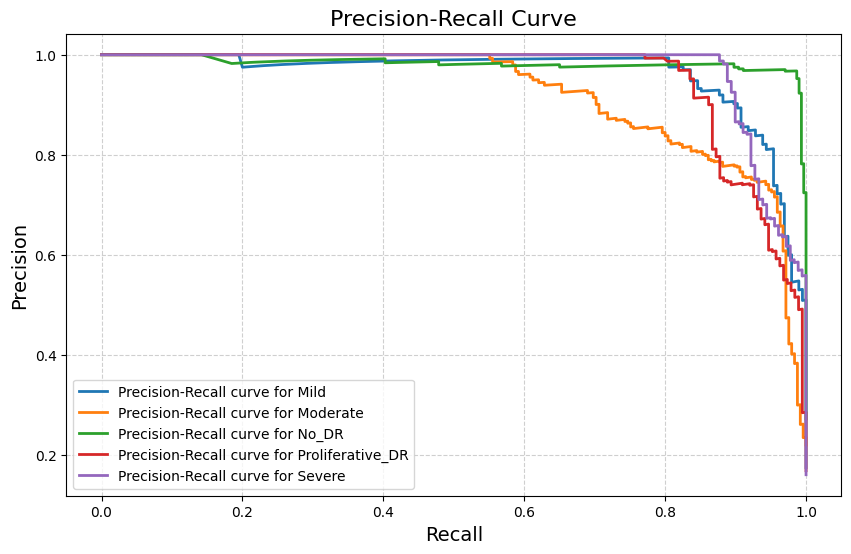

In [32]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision and recall for each class
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true == i, y_pred_probs[:, i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], lw=2, label=f'Precision-Recall curve for {class_names[i]}')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve', fontsize=16)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

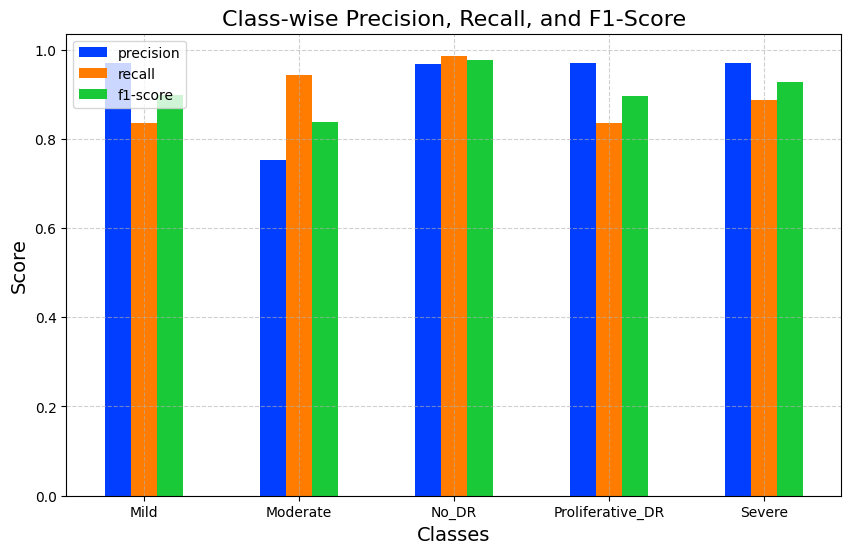

In [49]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# Calculate precision, recall, f1-score
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])

# Plot bar chart for precision, recall, and F1-score
df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6), color=sns.color_palette("bright"))
plt.title('Class-wise Precision, Recall, and F1-Score', fontsize=16)
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


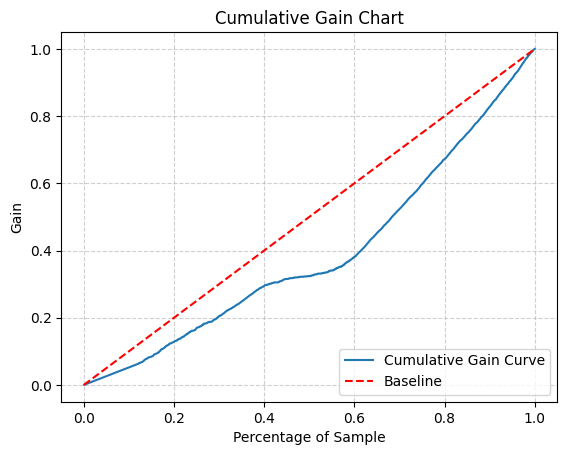

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_gain(y_true, y_pred_probs):
    y_true = np.array(y_true)
    order = np.argsort(y_pred_probs[:, 1])[::-1]
    y_true_sorted = y_true[order]

    # Cumulative Gain
    cumulative_gains = np.cumsum(y_true_sorted) / np.sum(y_true_sorted)
    
    plt.plot(np.arange(1, len(y_true) + 1) / len(y_true), cumulative_gains, label='Cumulative Gain Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Baseline')

    plt.xlabel('Percentage of Sample')
    plt.ylabel('Gain')
    plt.title('Cumulative Gain Chart')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Assuming binary classification with class 1 as positive
plot_cumulative_gain(y_true, y_pred_probs)

C:\Users\apara\AppData\Local\Temp\ipykernel_289376\1910630440.py:7: RuntimeWarning: divide by zero encountered in divide
  lift = cumulative_gains / np.linspace(0, 1, len(y_true))


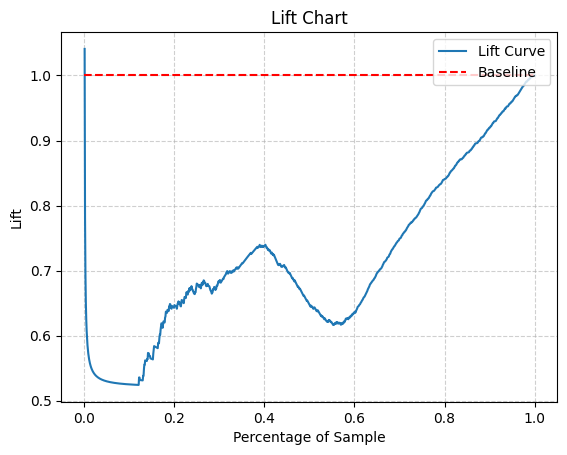

In [38]:
def plot_lift_chart(y_true, y_pred_probs):
    y_true = np.array(y_true)
    order = np.argsort(y_pred_probs[:, 1])[::-1]
    y_true_sorted = y_true[order]

    cumulative_gains = np.cumsum(y_true_sorted) / np.sum(y_true_sorted)
    lift = cumulative_gains / np.linspace(0, 1, len(y_true))

    plt.plot(np.arange(1, len(y_true) + 1) / len(y_true), lift, label='Lift Curve')
    plt.plot([0, 1], [1, 1], linestyle='--', color='red', label='Baseline')

    plt.xlabel('Percentage of Sample')
    plt.ylabel('Lift')
    plt.title('Lift Chart')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_lift_chart(y_true, y_pred_probs)


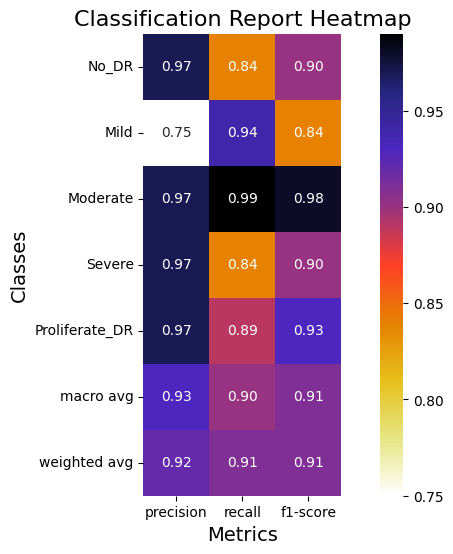

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your classification report data
report = {
    'No_DR': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 195},
    'Mild': {'precision': 0.75, 'recall': 0.94, 'f1-score': 0.84, 'support': 245},
    'Moderate': {'precision': 0.97, 'recall': 0.99, 'f1-score': 0.98, 'support': 303},
    'Severe': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 188},
    'Proliferate_DR': {'precision': 0.97, 'recall': 0.89, 'f1-score': 0.93, 'support': 179},
    'accuracy': {'precision': None, 'recall': None, 'f1-score': None, 'support': 1110},
    'macro avg': {'precision': 0.93, 'recall': 0.90, 'f1-score': 0.91, 'support': 1110},
    'weighted avg': {'precision': 0.92, 'recall': 0.91, 'f1-score': 0.91, 'support': 1110}
}

# Convert the classification report to a DataFrame
report_df = pd.DataFrame(report).transpose()

# Remove the 'accuracy' row for visualization
report_df = report_df.drop('accuracy')

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:, :-1], annot=True, fmt=".2f", cmap='CMRmap_r', cbar=True, square=True)
plt.title('Classification Report Heatmap', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Classes', fontsize=14)
plt.xticks(rotation=0)
plt.show()


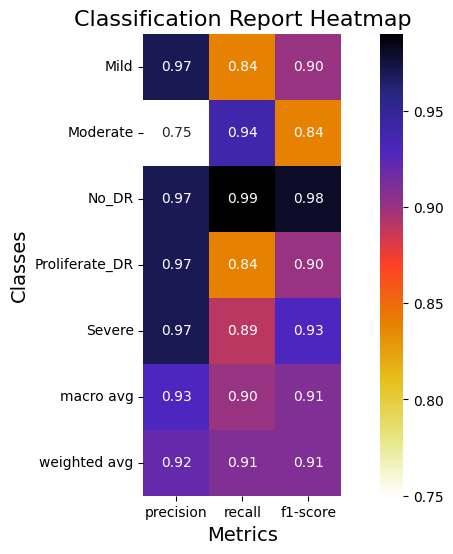

In [4]:
#CORRECT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your classification report data
report = {
    'Mild': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 195},
    'Moderate': {'precision': 0.75, 'recall': 0.94, 'f1-score': 0.84, 'support': 245},
    'No_DR': {'precision': 0.97, 'recall': 0.99, 'f1-score': 0.98, 'support': 303},
    'Proliferate_DR': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 188},
    'Severe': {'precision': 0.97, 'recall': 0.89, 'f1-score': 0.93, 'support': 179},
    'accuracy': {'precision': None, 'recall': None, 'f1-score': None, 'support': 1110},
    'macro avg': {'precision': 0.93, 'recall': 0.90, 'f1-score': 0.91, 'support': 1110},
    'weighted avg': {'precision': 0.92, 'recall': 0.91, 'f1-score': 0.91, 'support': 1110}
}

# Convert the classification report to a DataFrame
report_df = pd.DataFrame(report).transpose()

# Remove the 'accuracy' row for visualization
report_df = report_df.drop('accuracy')

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:, :-1], annot=True, fmt=".2f", cmap='CMRmap_r', cbar=True, square=True)
plt.title('Classification Report Heatmap', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Classes', fontsize=14)
plt.xticks(rotation=0)
plt.show()


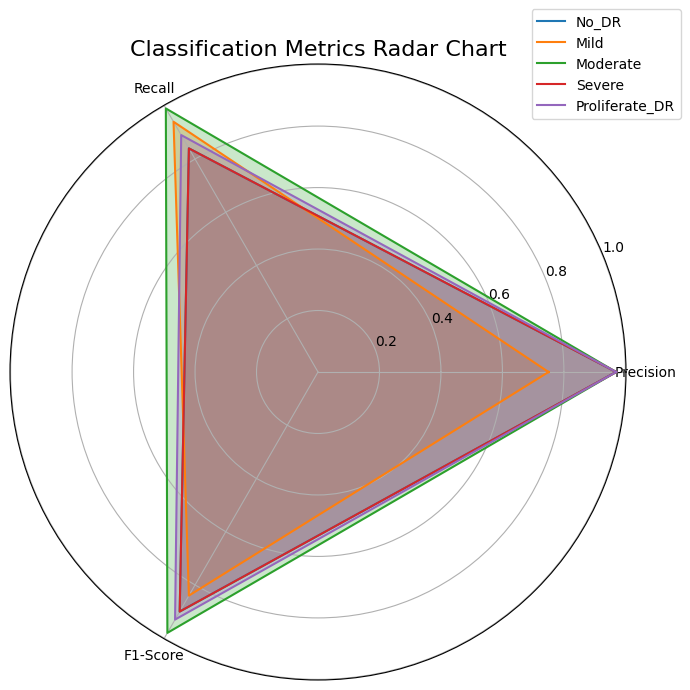

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Data preparation for radar chart
labels = report_df.index
num_vars = len(labels)

# Create a 2D array for the metrics
metrics = report_df[['precision', 'recall', 'f1-score']].values

# Adjust for radar chart
num_metrics = metrics.shape[1]  # Number of metrics (3 in this case)
metrics = np.concatenate((metrics, metrics[:, [0]]), axis=1)  # Close the loop for metrics
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()  # Angles for metrics
angles += angles[:1]  # Close the loop for angles

# Create the radar chart
plt.figure(figsize=(8, 8))
for i in range(metrics.shape[0]):
    plt.subplot(1, 1, 1, polar=True)
    plt.fill(angles, metrics[i], alpha=0.25)
    plt.plot(angles, metrics[i], label=labels[i])

plt.title('Classification Metrics Radar Chart', fontsize=16)
plt.xticks(angles[:-1], ['Precision', 'Recall', 'F1-Score'])
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()


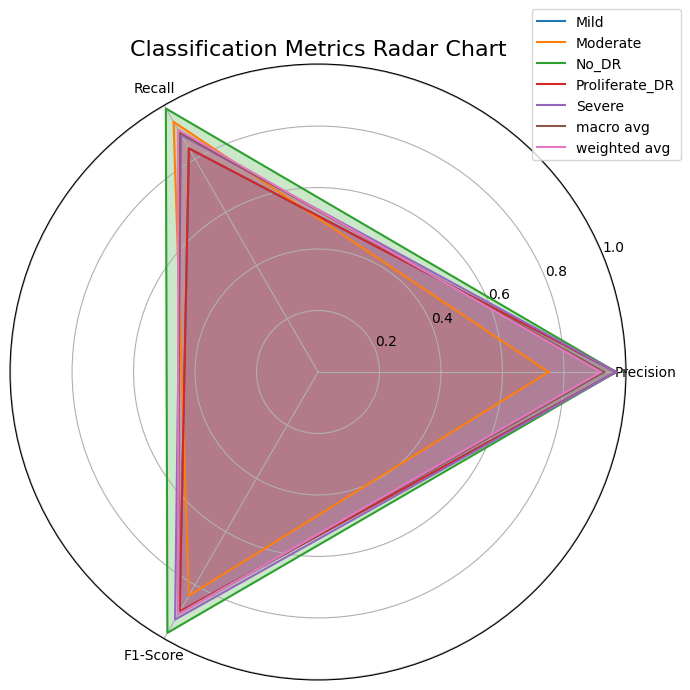

In [5]:
#CORRECT

import numpy as np
import matplotlib.pyplot as plt

# Data preparation for radar chart
labels = report_df.index
num_vars = len(labels)

# Create a 2D array for the metrics
metrics = report_df[['precision', 'recall', 'f1-score']].values

# Adjust for radar chart
num_metrics = metrics.shape[1]  # Number of metrics (3 in this case)
metrics = np.concatenate((metrics, metrics[:, [0]]), axis=1)  # Close the loop for metrics
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()  # Angles for metrics
angles += angles[:1]  # Close the loop for angles

# Create the radar chart
plt.figure(figsize=(8, 8))
for i in range(metrics.shape[0]):
    plt.subplot(1, 1, 1, polar=True)
    plt.fill(angles, metrics[i], alpha=0.25)
    plt.plot(angles, metrics[i], label=labels[i])

plt.title('Classification Metrics Radar Chart', fontsize=16)
plt.xticks(angles[:-1], ['Precision', 'Recall', 'F1-Score'])
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()


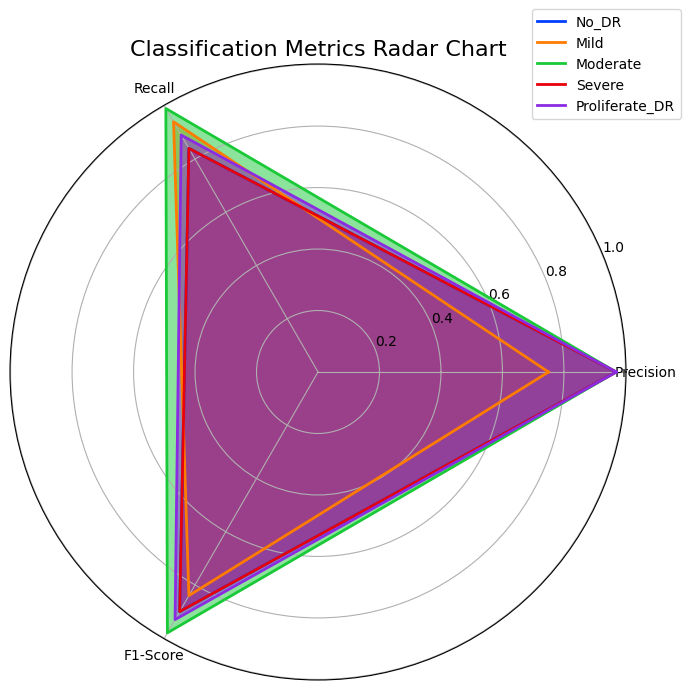

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation for radar chart
labels = report_df.index
num_vars = len(labels)

# Create a 2D array for the metrics
metrics = report_df[['precision', 'recall', 'f1-score']].values

# Adjust for radar chart
num_metrics = metrics.shape[1]  # Number of metrics (3 in this case)
metrics = np.concatenate((metrics, metrics[:, [0]]), axis=1)  # Close the loop for metrics
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()  # Angles for metrics
angles += angles[:1]  # Close the loop for angles

# Create the radar chart
plt.figure(figsize=(8, 8))

# Use Seaborn to get a color palette
palette = sns.color_palette("bright", metrics.shape[0])  # You can choose other palettes like "deep", "bright", etc.

for i in range(metrics.shape[0]):
    plt.subplot(1, 1, 1, polar=True)
    plt.fill(angles, metrics[i], color=palette[i], alpha=0.5)  # Fill with palette color
    plt.plot(angles, metrics[i], color=palette[i], linewidth=2, label=labels[i])  # Thicker lines

plt.title('Classification Metrics Radar Chart', fontsize=16)
plt.xticks(angles[:-1], ['Precision', 'Recall', 'F1-Score'])
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()
